# Experimento 03 — Ensemble com Voto Majoritario

Neste notebook, combinei as previsoes dos 5 modelos base (SVM, KNN, Extra Trees, Regressao Logistica e LightGBM) usando **voto majoritario**.

A ideia e simples: para cada jogo, cada modelo da seu palpite (0 ou 1), o resultado final e aquele que recebeu 3 ou mais votos entre os 5 modelos.

### Etapas:
1. Carregar os CSVs detalhados dos 5 modelos
2. Para cada janela, montar um pivot com as previsoes e aplicar o voto majoritario
3. Calcular acuracia e F1-Score por temporada
4. Salvar o CSV com os resultados do ensemble
5. Plotar graficos comparando o ensemble com os modelos individuais

## Importar bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Configuracao

- `PASTA`: pasta onde estao os CSVs detalhados de predicao dos 5 modelos
- `SAIDA`: pasta onde o CSV do ensemble sera salvo
- `ARQUIVOS`: mapeamento de cada modelo para seu CSV detalhado
- `CHAVE_JOGO`: colunas que, juntas, identificam um jogo unico

In [2]:
PASTA = os.path.abspath(os.path.join('..', 'results', 'experimento_03_detalhado'))
SAIDA = os.path.abspath(os.path.join('..', 'results', 'experimento_03'))

ARQUIVOS = {
    'svm':                'svm_experimento_03_predicoes_detalhadas.csv',
    'knn':                'knn_experimento_03_predicoes_detalhadas.csv',
    'extra_trees':        'extra_trees_experimento_03_predicoes_detalhadas.csv',
    'regressao_logistica':'regressao_logistica_experimento_03_predicoes_detalhadas.csv',
    'lightgbm':           'lightgbm_experimento_03_predicoes_detalhadas.csv',
}

CHAVE_JOGO = ['Temporada', 'Data Jogo', 'Round', 'Posicao no Teste']

print('Pasta:', PASTA)
print('Saida:', SAIDA)
print('Modelos:', list(ARQUIVOS.keys()))

Pasta: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_03_detalhado
Saida: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_03
Modelos: ['svm', 'knn', 'extra_trees', 'regressao_logistica', 'lightgbm']


## Carregar os CSVs detalhados

Cada CSV contem as predicoes de um modelo. Aqui lemos todos e juntamos em um unico DataFrame, adicionando a coluna `_modelo` para identificar de qual algoritmo veio cada linha.

In [3]:
dfs = []
for modelo, arquivo in ARQUIVOS.items():
    caminho = os.path.join(PASTA, arquivo)
    df = pd.read_csv(caminho)
    df['_modelo'] = modelo
    dfs.append(df)

dados = pd.concat(dfs, ignore_index=True)

print(f'Total de linhas: {len(dados)}')
print(f'Janelas disponiveis: {sorted(dados["Janela Incremental"].unique())}')
print(f'Modelos: {list(dados["_modelo"].unique())}')

Total de linhas: 53700
Janelas disponiveis: [np.int64(5), np.int64(10), np.int64(15)]
Modelos: ['svm', 'knn', 'extra_trees', 'regressao_logistica', 'lightgbm']


## Calcular o Voto Majoritario

Para cada janela incremental 5, 10, 15:

1. Filtra os dados da janela e removemos duplicatas
2. Cria um **pivot**, ele funciona assim: cada linha vira um jogo, cada coluna uma previsao de um modelo
3. Mantem apenas jogos onde **todos os 5 modelos** fizeram previsãoo
4. Soma os votos (cada modelo vota 0 ou 1) e o resultado do ensemble e `1` se tiver **3 ou mais** votos
5. Calcula acuracia e F1-Score por temporada

No final é salvo o csv com os resultados

In [4]:
resultados = []

for janela in [5, 10, 15]:
    dados_janela = dados[dados['Janela Incremental'] == janela].copy()

    dados_janela = dados_janela.drop_duplicates(
        subset=CHAVE_JOGO + ['_modelo'], keep='first'
    )

    pivot_prev = dados_janela.pivot(
        index=CHAVE_JOGO, columns='_modelo', values='Previsao'
    )
    pivot_real = (
        dados_janela
        .drop_duplicates(subset=CHAVE_JOGO)
        .set_index(CHAVE_JOGO)['Resultado Real']
    )

    idx_comum = pivot_prev.dropna().index
    pivot_prev = pivot_prev.loc[idx_comum]
    y_real     = pivot_real.loc[idx_comum]

    soma_votos        = pivot_prev.sum(axis=1)
    previsao_ensemble = (soma_votos >= 3).astype(int)

    temporadas = [idx[0] for idx in idx_comum]
    df_resultado = pd.DataFrame({
        'Temporada':          temporadas,
        'Previsao Ensemble':  previsao_ensemble.values,
        'Resultado Real':     y_real.values,
    })

    for temporada, grupo in df_resultado.groupby('Temporada'):
        acuracia = (grupo['Previsao Ensemble'] == grupo['Resultado Real']).mean()
        f1       = f1_score(
            grupo['Resultado Real'],
            grupo['Previsao Ensemble'],
            average='weighted',
            zero_division=0
        )
        resultados.append({
            'Janela Incremental': janela,
            'Temporada':          temporada,
            'Acur\u00e1cia':           round(acuracia, 4),
            'F1-Score':           round(f1, 4),
        })

    print(f'Janela {janela} \u2014 jogos avaliados: {len(idx_comum)}')

df_voto = pd.DataFrame(resultados)
os.makedirs(SAIDA, exist_ok=True)
saida_path = os.path.join(SAIDA, 'ensemble_voto_majoritario.csv')
df_voto.to_csv(saida_path, index=False)

print(f'\nResultados salvos em: {saida_path}')
print(df_voto.to_string(index=False))

Janela 5 — jogos avaliados: 1604
Janela 10 — jogos avaliados: 1578
Janela 15 — jogos avaliados: 1552

Resultados salvos em: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_03\ensemble_voto_majoritario.csv
 Janela Incremental Temporada  Acurácia  F1-Score
                  5 2008-2009    0.7042    0.6764
                  5 2009-2010    0.7805    0.7522
                  5 2011-2012    0.6094    0.5622
                  5 2012-2013    0.6518    0.6163
                  5 2013-2014    0.6238    0.6074
                  5 2014-2015    0.6512    0.6209
                  5 2015-2016    0.6047    0.5941
                  5 2016-2017    0.5714    0.5670
                  5 2018-2019    0.6522    0.6437
                  5 2019-2020    0.6261    0.6251
                  5 2020-2021    0.6694    0.6596
                  5 2021-2022    0.6618    0.6537
                  5 2022-2023    0.5753    0.5653
                  5 2023-2024    0.6273    0.6196
              

## Funcao Plot

A funcao `plot_linhas_com_ensemble(janela)` gera um grafico com duas partes:

- **Painel superior**: linhas de acuracia por temporada para cada modelo individual + a linha tracejada preta do voto majoritario
- **Painel inferior**: barras mostrando a quantidade de jogos avaliados por temporada

Ao final, exibe uma tabela resumo com media e desvio padrao de acuracia para cada modelo e para o ensemble.

In [5]:
def plot_linhas_com_ensemble(janela):
    base_path = os.path.abspath(os.path.join('..', 'results', 'experimento_03'))

    modelos = {
        'SVM':                'svm',
        'KNN':                'knn',
        'Extra Trees':        'extra_trees',
        'Regressao Logistica':'regressao_logistica',
        'LightGBM':           'lightgbm',
    }

    jogos_por_temporada = {
        '2008-2009': 237, '2009-2010': 162, '2011-2012': 176,
        '2012-2013': 350, '2013-2014': 316, '2014-2015': 285,
        '2015-2016': 255, '2016-2017': 260, '2018-2019': 218,
        '2019-2020': 207, '2020-2021': 266, '2021-2022': 304,
        '2022-2023': 312, '2023-2024': 386
    }

    cores = {
        'SVM':                '#1f77b4',
        'KNN':                '#ff7f0e',
        'Extra Trees':        '#2ca02c',
        'Regressao Logistica':'#d62728',
        'LightGBM':           '#9467bd',
    }

    marcadores = {
        'SVM':                'o',
        'KNN':                's',
        'Extra Trees':        '^',
        'Regressao Logistica':'D',
        'LightGBM':           'P',
    }

    temporadas_order = list(jogos_por_temporada.keys())

    dfs_plot = []
    for nome_modelo, arquivo_modelo in modelos.items():
        path = os.path.join(
            base_path,
            f'{arquivo_modelo}_experimento_03_janela{janela}.csv'
        )
        if not os.path.exists(path):
            print(f'Arquivo nao encontrado: {path}')
            continue
        df_m = pd.read_csv(path)
        df_m['Modelo'] = nome_modelo
        dfs_plot.append(df_m)

    dados_plot = pd.concat(dfs_plot, ignore_index=True)
    dados_plot['Acur\u00e1cia'] = dados_plot['Acur\u00e1cia'].astype(float)
    dados_plot['Temporada'] = pd.Categorical(
        dados_plot['Temporada'], categories=temporadas_order, ordered=True
    )
    dados_plot = dados_plot.sort_values('Temporada')

    voto_path = os.path.join(base_path, 'ensemble_voto_majoritario.csv')
    df_voto = pd.read_csv(voto_path)
    df_voto = df_voto[df_voto['Janela Incremental'] == janela].copy()
    df_voto['Acur\u00e1cia'] = df_voto['Acur\u00e1cia'].astype(float)
    df_voto['Temporada'] = pd.Categorical(
        df_voto['Temporada'], categories=temporadas_order, ordered=True
    )
    df_voto = df_voto.sort_values('Temporada')

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    for nome_modelo in modelos.keys():
        subset = dados_plot[dados_plot['Modelo'] == nome_modelo].sort_values('Temporada')
        ax1.plot(
            subset['Temporada'],
            subset['Acur\u00e1cia'],
            marker=marcadores[nome_modelo],
            color=cores[nome_modelo],
            linewidth=2,
            markersize=6,
            label=nome_modelo,
            alpha=0.75
        )

    ax1.plot(
        df_voto['Temporada'],
        df_voto['Acur\u00e1cia'],
        marker='*',
        color='black',
        linewidth=2.5,
        markersize=10,
        linestyle='--',
        label='Voto Majoritario',
        zorder=5
    )

    ax1.set_title(
        f'Experimento 03 \u2014 Acuracia por temporada | Janela = {janela}',
        fontsize=14
    )
    ax1.set_ylabel('Acuracia', fontsize=12)
    ax1.set_ylim(0.50, 0.85)
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    temporadas_presentes = [t for t in temporadas_order if t in jogos_por_temporada]
    jogos_vals = [jogos_por_temporada[t] for t in temporadas_presentes]

    ax2.bar(
        temporadas_presentes, jogos_vals,
        color='#1f77b4', alpha=0.4, edgecolor='#1f77b4'
    )
    for i, v in enumerate(jogos_vals):
        ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)

    ax2.set_ylabel('Jogos', fontsize=10)
    ax2.set_ylim(0, max(jogos_vals) * 1.25)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    resumo_modelos = (
        dados_plot.groupby('Modelo')['Acur\u00e1cia']
             .agg(Media='mean', Desvio='std')
             .round(4)
    )
    resumo_voto = pd.DataFrame({
        'Media':  [df_voto['Acur\u00e1cia'].mean().round(4)],
        'Desvio': [df_voto['Acur\u00e1cia'].std().round(4)],
    }, index=['Voto Majoritario'])

    resumo = pd.concat([resumo_modelos, resumo_voto]).sort_values(
        'Media', ascending=False
    )

    plt.tight_layout()
    plt.show()

    print(f'\nJanela = {janela}')
    print(resumo.to_string())
    print()

## Visualizacao — Acuracia por temporada

grafico comparativo para cada uma das 3 janelas incrementais (5, 10, 15).

Cada grafico mostra:
- As 5 linhas coloridas dos modelos individuais
- A linha preta tracejada do voto majoritario
- Barras com a quantidade de jogos por temporada

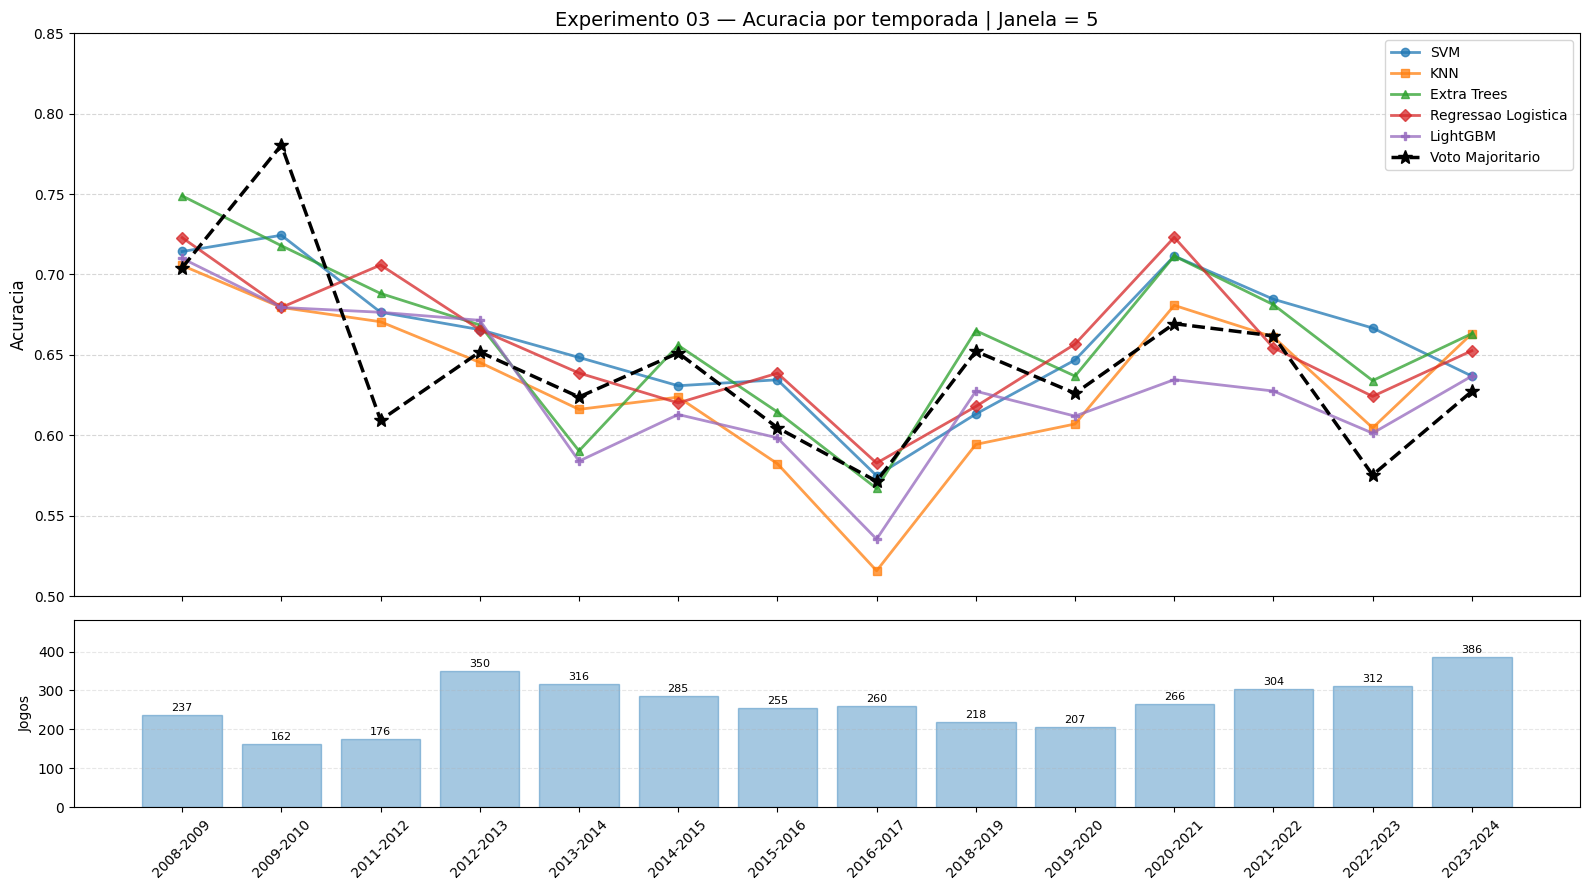


Janela = 5
                      Media  Desvio
Extra Trees          0.6602  0.0497
SVM                  0.6592  0.0416
Regressao Logistica  0.6559  0.0410
Voto Majoritario     0.6435  0.0534
KNN                  0.6321  0.0501
LightGBM             0.6291  0.0450



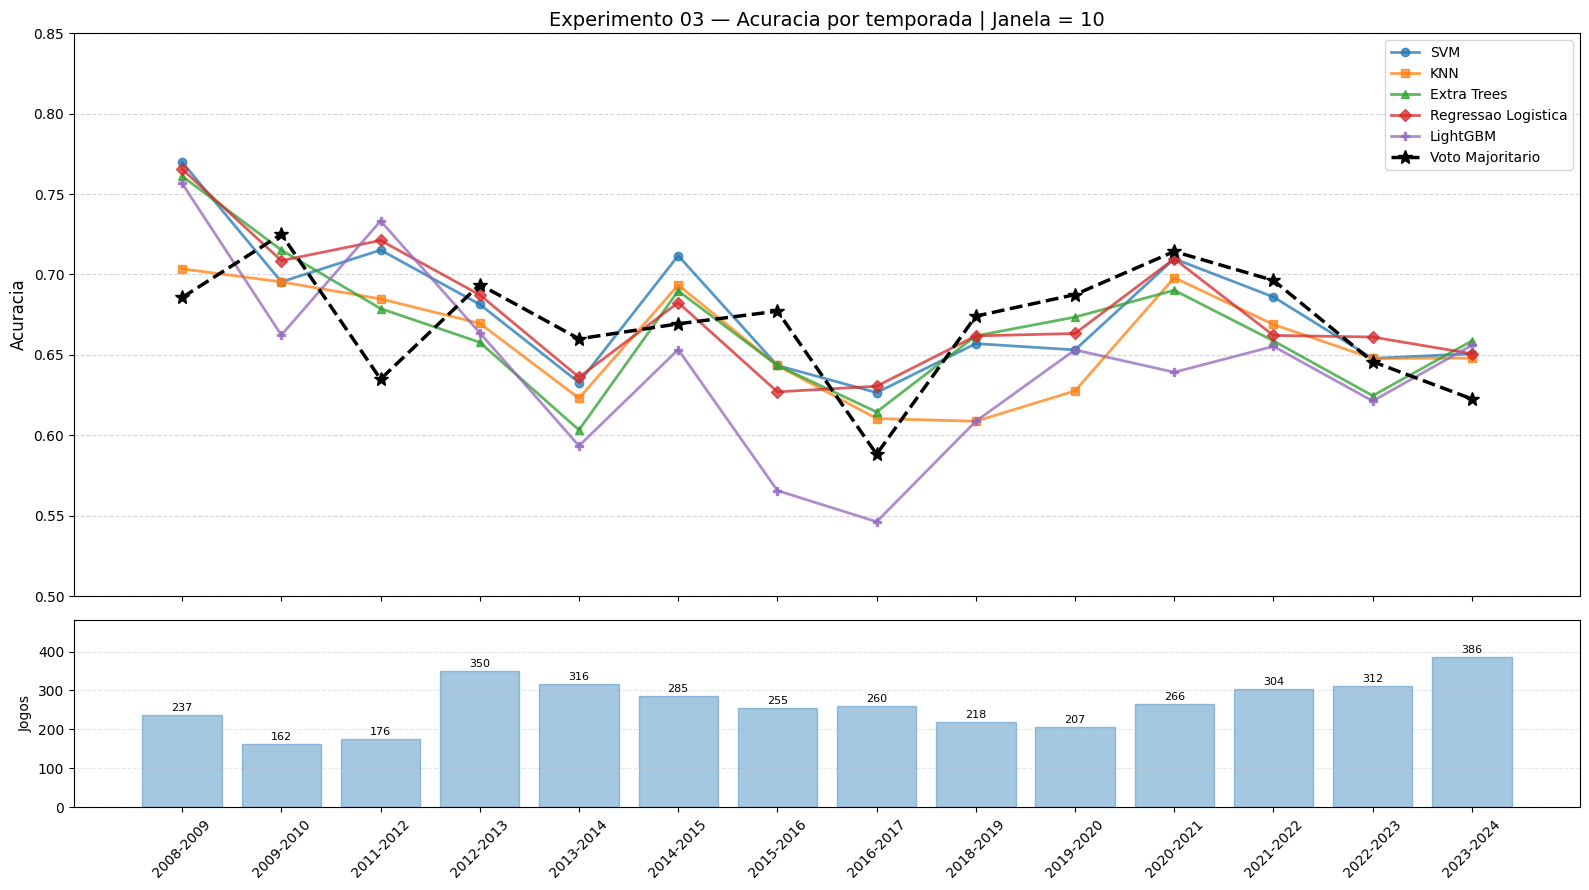


Janela = 10
                      Media  Desvio
SVM                  0.6772  0.0402
Regressao Logistica  0.6762  0.0391
Voto Majoritario     0.6696  0.0369
Extra Trees          0.6665  0.0410
KNN                  0.6588  0.0335
LightGBM             0.6434  0.0568



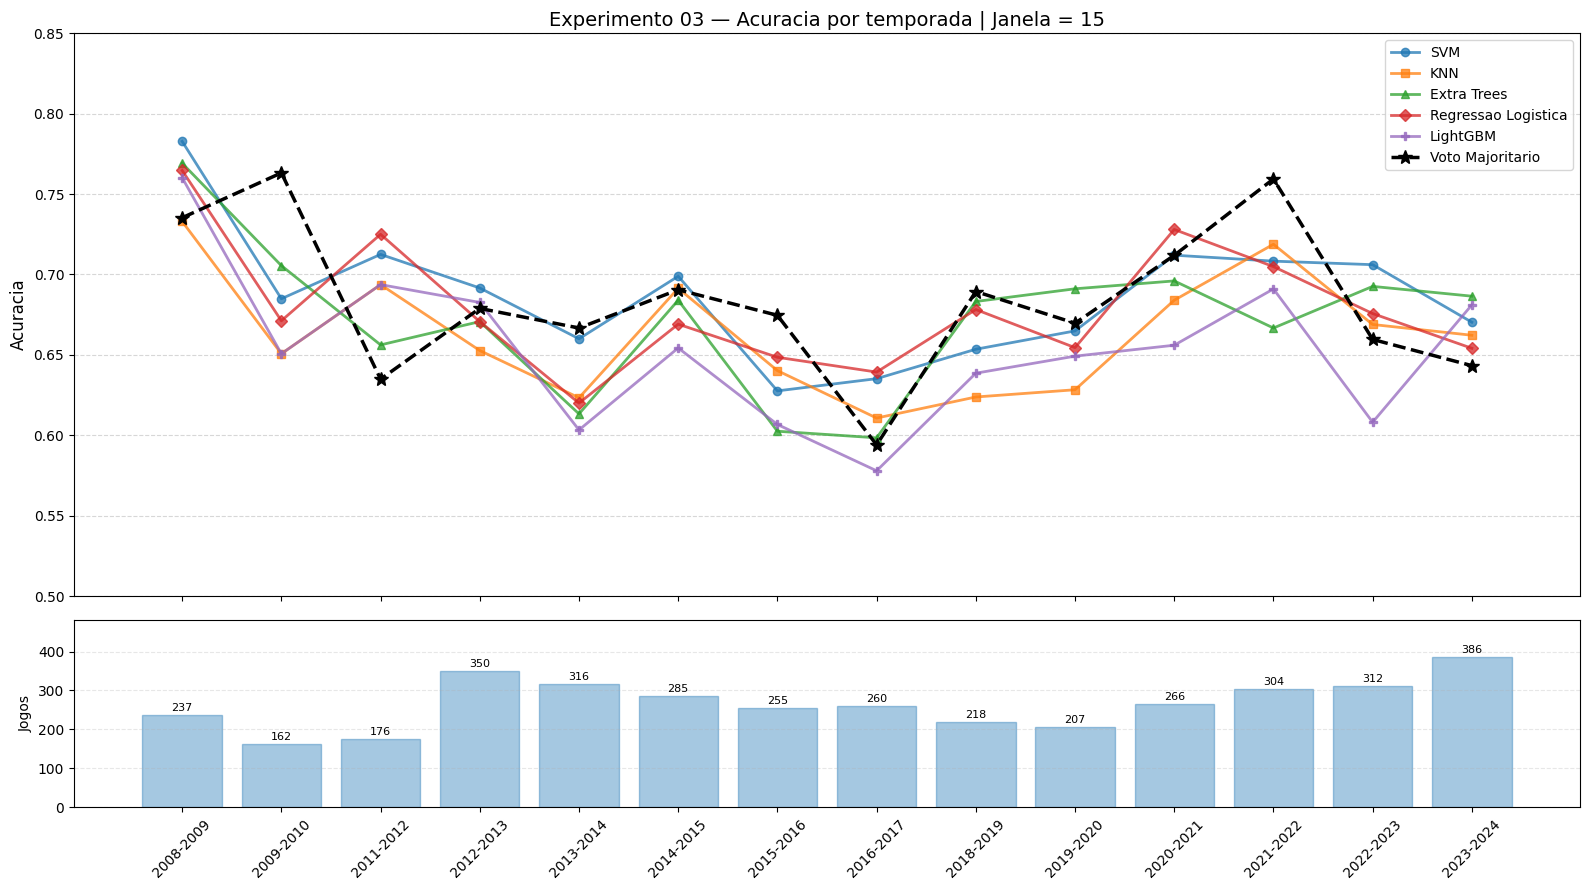


Janela = 15
                      Media  Desvio
SVM                  0.6863  0.0395
Voto Majoritario     0.6837  0.0471
Regressao Logistica  0.6788  0.0392
Extra Trees          0.6726  0.0450
KNN                  0.6630  0.0373
LightGBM             0.6538  0.0470



In [6]:
for janela in [5, 10, 15]:
    plot_linhas_com_ensemble(janela)